## Learning Objectives

* Understand the importance of stratified splitting for imbalanced datasets
* Build production-ready models using sklearn pipelines with `ColumnTransformer`
* Interpret confusion matrices and identify different types of prediction errors
* Calculate and understand precision, recall, and F1 score
* Analyze the precision-recall tradeoff when changing classification thresholds
* Evaluate models using ROC curves and AUC scores
* Choose appropriate evaluation metrics based on the problem context and costs of different error types

##  Import Libraries and Load Data

We will use the same titanic dataset and model preparation as the previous chapter for this chapter


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# For statsmodels implementation
import statsmodels.formula.api as smf

# For sklearn implementation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Titanic dataset
titanic = sns.load_dataset('titanic')

print(f"Dataset shape: {titanic.shape}")
print(f"\nFirst few rows:")
titanic.head()

Dataset shape: (891, 15)

First few rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


##  Data Preparation

### Imputing missing values


Like linear regression, logistic regression does not tolerate missing values

We'll focus on:

- **Target variable:** `survived` (0 = died, 1 = survived)
- **Predictors:** `age`, `fare`, `sex`, `pclass`

Let's check for missing values in these columns


In [3]:
# Check for missing values in our columns of interest
columns_of_interest = ['survived', 'age', 'fare', 'sex', 'pclass']
print("Missing values in columns of interest:")
print(titanic[columns_of_interest].isnull().sum())

Missing values in columns of interest:
survived      0
age         177
fare          0
sex           0
pclass        0
dtype: int64


There are 177 missing values in Age, which is a key predictor. Dropping all rows with missing values would result in a substantial loss of useful information. A simple and reasonable approach is group-wise median imputation: fill in missing ages using the median Age within each combination of `Sex` and `Pclass`.

In [4]:
# impute median age for each combination of sex and pclass
titanic['age'] = titanic.groupby(['sex', 'pclass'])['age'].transform(lambda x: x.fillna(x.median()))

Let's check again

In [5]:
columns_of_interest = ['survived', 'age', 'fare', 'sex', 'pclass']
print("Missing values in columns of interest:")
print(titanic[columns_of_interest].isnull().sum())

Missing values in columns of interest:
survived    0
age         0
fare        0
sex         0
pclass      0
dtype: int64


### Check Target Distribution

Let’s examine the distribution of the target variable to determine whether the dataset is balanced.

In [6]:
# Quick exploratory analysis
print("Target variable distribution:")
print(titanic['survived'].value_counts())

Target variable distribution:
survived
0    549
1    342
Name: count, dtype: int64


## Stratified Splitting 

The dataset shows moderate class imbalance (about 62% non-survived vs 38% survived).

For such datasets, we need to do **stratified splitting** to make sure the proportion of classes is preserved in both train and test sets.

**How to do stratified splitting:**

Use the `stratify` parameter in `train_test_split()`:

```python
train_df, test_df = train_test_split(
    titanic, 
    test_size=0.2, 
    random_state=42, 
    stratify=titanic['survived']  # Pass the target variable here, or stratify=y
)
```

This ensures that both train and test sets have the same class distribution as the original dataset.

In [12]:
# Compare random vs stratified splitting
print("ORIGINAL DATASET:")
original_props = titanic['survived'].value_counts(normalize=True)
print(f"  Survived: {original_props[1]:.1%} | Died: {original_props[0]:.1%}")

# Random splitting (without stratify)
train_random, test_random = train_test_split(titanic, test_size=0.2, random_state=42)
print("\nRANDOM SPLIT (without stratify):")
print(f"  Train - Survived: {train_random['survived'].mean():.1%}")
print(f"  Test  - Survived: {test_random['survived'].mean():.1%}")

# Stratified splitting (with stratify)
train_strat, test_strat = train_test_split(titanic, test_size=0.2, random_state=42, 
                                            stratify=titanic['survived'])
print("\nSTRATIFIED SPLIT (with stratify):")
print(f"  Train - Survived: {train_strat['survived'].mean():.1%}")
print(f"  Test  - Survived: {test_strat['survived'].mean():.1%}")

print("\n✓ Stratified splitting maintains the same proportions in both sets")
print("✓ This ensures reliable model evaluation, especially for imbalanced data")

ORIGINAL DATASET:
  Survived: 38.4% | Died: 61.6%

RANDOM SPLIT (without stratify):
  Train - Survived: 37.6%
  Test  - Survived: 41.3%

STRATIFIED SPLIT (with stratify):
  Train - Survived: 38.3%
  Test  - Survived: 38.5%

✓ Stratified splitting maintains the same proportions in both sets
✓ This ensures reliable model evaluation, especially for imbalanced data


In [14]:
# Split into train and test sets with stratification for the rest of the tasks
train_df, test_df = train_test_split(titanic, test_size=0.2, random_state=42, stratify=titanic['survived'])

##  Scikit-learn Implementation

Since `sklearn` is optimized for **prediction and machine learning workflows**. we will stick with `sklearn`

### Pipeline Implementation

**Why use Pipelines?**

In the previous chapter, we've manually created dummy variables using `pd.get_dummies()`. While this works, sklearn's **Pipeline** approach offers several advantages:

1. **Automated preprocessing**: Handles categorical encoding automatically
2. **Prevents data leakage**: Ensures transformations are fit only on training data
3. **Cleaner code**: Combines preprocessing and modeling in one object
4. **Production-ready**: Easier to deploy and maintain
5. **Reproducibility**: All steps are encapsulated in one pipeline

**Key components:**

- `ColumnTransformer`: Applies different transformations to different columns
- `OneHotEncoder`: Converts categorical variables to dummy variables
- `Pipeline`: Chains preprocessing and model fitting together

Let's implement the same logistic regression model using a pipeline (with regularization to match statsmodels):

In [20]:
# Import required components for pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Define which columns are categorical and which are numeric
categorical_features = ['sex']
numeric_features = ['age', 'fare', 'pclass']

y_train = train_df['survived']
y_test = test_df['survived']

# Create the column transformer
# OneHotEncoder with drop='first' mimics the drop_first=True in pd.get_dummies
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),  # Keep numeric features as-is
        ('cat', OneHotEncoder(drop='first'), categorical_features)  # Encode categorical
    ])

# Create the pipeline: preprocessing + logistic regression
pipeline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# Fit the pipeline on training data
# Note: We pass the original dataframe with categorical variables
X_train_raw = train_df[['age', 'fare', 'sex', 'pclass']]
X_test_raw = test_df[['age', 'fare', 'sex', 'pclass']]

pipeline_model.fit(X_train_raw, y_train)

print("Pipeline model fitted successfully!")
print("\nPipeline structure:")
print(pipeline_model)

Pipeline model fitted successfully!

Pipeline structure:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'fare', 'pclass']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex'])])),
                ('classifier', LogisticRegression(random_state=42))])


In [21]:
# Extract the trained logistic regression model from the pipeline
pipeline_logit = pipeline_model.named_steps['classifier']

# Get feature names after transformation
feature_names = numeric_features + ['sex_male']  # OneHotEncoder creates sex_male (drops sex_female)

print("Pipeline Logistic Regression Coefficients (C=np.inf):")
print(f"\nCoefficients:")
for feature, coef in zip(feature_names, pipeline_logit.coef_[0]):
    print(f"  {feature:20s}: {coef:8.4f}")
print(f"\nIntercept: {pipeline_logit.intercept_[0]:.4f}")

# Make predictions
pipeline_train_pred = pipeline_model.predict(X_train_raw)
pipeline_test_pred = pipeline_model.predict(X_test_raw)

# Calculate accuracy
pipeline_train_accuracy = accuracy_score(y_train, pipeline_train_pred)
pipeline_test_accuracy = accuracy_score(y_test, pipeline_test_pred)

print(f"\nPipeline Model Performance:")
print(f"  Training Accuracy:   {pipeline_train_accuracy:.4f} ({pipeline_train_accuracy:.2%})")
print(f"  Test Accuracy:       {pipeline_test_accuracy:.4f} ({pipeline_test_accuracy:.2%})")

Pipeline Logistic Regression Coefficients (C=np.inf):

Coefficients:
  age                 :  -0.0389
  fare                :   0.0010
  pclass              :  -1.2189
  sex_male            :  -2.4830

Intercept: 4.8699

Pipeline Model Performance:
  Training Accuracy:   0.8006 (80.06%)
  Test Accuracy:       0.7821 (78.21%)


## Performance Evaluation

The dataset shows moderate class imbalance (about 62% non-survived vs 38% survived). While accuracy is a useful metric, for imbalanced datasets we should consider additional metrics:

- **Confusion Matrix**: Shows the breakdown of correct and incorrect predictions
- **Precision**: Of all positive predictions, how many were correct?
- **Recall (Sensitivity)**: Of all actual positives, how many did we find?
- **F1 Score**: Harmonic mean of precision and recall
- **ROC-AUC**: Overall measure of model discrimination ability

Let's evaluate our model using these metrics.

### Confusion Matrix

A confusion matrix shows the breakdown of predictions:

|                  | Predicted: 0 (Died) | Predicted: 1 (Survived) |
|------------------|---------------------|-------------------------|
| **Actual: 0**    | True Negative (TN)  | False Positive (FP)     |
| **Actual: 1**    | False Negative (FN) | True Positive (TP)      |

- **True Positives (TP)**: Correctly predicted survivors
- **True Negatives (TN)**: Correctly predicted deaths
- **False Positives (FP)**: Predicted survival but actually died (Type I error)
- **False Negatives (FN)**: Predicted death but actually survived (Type II error)

Confusion Matrix:
                 Predicted
                 Died | Survived
Actual Died        91 |   19
Actual Survived    20 |   49


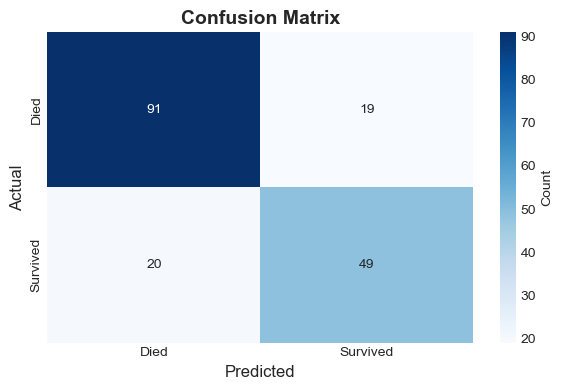


Breakdown:
  True Negatives (TN):  91 - Correctly predicted deaths
  False Positives (FP): 19 - Incorrectly predicted survival
  False Negatives (FN): 20 - Incorrectly predicted death
  True Positives (TP):  49 - Correctly predicted survival


In [23]:
# Generate predictions on test set
y_pred = pipeline_model.predict(X_test_raw)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print("="*50)
print(f"                 Predicted")
print(f"                 Died | Survived")
print(f"Actual Died      {cm[0,0]:4d} | {cm[0,1]:4d}")
print(f"Actual Survived  {cm[1,0]:4d} | {cm[1,1]:4d}")
print("="*50)

# Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Died', 'Survived'], 
            yticklabels=['Died', 'Survived'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nBreakdown:")
print(f"  True Negatives (TN):  {cm[0,0]} - Correctly predicted deaths")
print(f"  False Positives (FP): {cm[0,1]} - Incorrectly predicted survival")
print(f"  False Negatives (FN): {cm[1,0]} - Incorrectly predicted death")
print(f"  True Positives (TP):  {cm[1,1]} - Correctly predicted survival")

### Precision, Recall, and F1 Score

**Precision** = $\frac{TP}{TP + FP}$ = "Of all predicted survivors, how many actually survived?"

- Focuses on the quality of positive predictions
- High precision = few false alarms

**Recall (Sensitivity)** = $\frac{TP}{TP + FN}$ = "Of all actual survivors, how many did we correctly identify?"

- Focuses on finding all positive cases
- High recall = few missed cases

**F1 Score** = $2 \times \frac{Precision \times Recall}{Precision + Recall}$ = Harmonic mean of precision and recall

- Balances precision and recall
- Useful when you need a single metric

In [24]:
# Calculate metrics from sklearn
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance Metrics:")
print("="*50)
print(f"Accuracy:  {accuracy:.4f} ({accuracy:.2%})")
print(f"Precision: {precision:.4f} ({precision:.2%})")
print(f"Recall:    {recall:.4f} ({recall:.2%})")
print(f"F1 Score:  {f1:.4f}")
print("="*50)

# Manual calculation to verify
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

manual_precision = TP / (TP + FP)
manual_recall = TP / (TP + FN)
manual_f1 = 2 * (manual_precision * manual_recall) / (manual_precision + manual_recall)

print("\nManual Calculation (verification):")
print(f"Precision = TP / (TP + FP) = {TP} / ({TP} + {FP}) = {manual_precision:.4f}")
print(f"Recall    = TP / (TP + FN) = {TP} / ({TP} + {FN}) = {manual_recall:.4f}")
print(f"F1 Score  = 2 * (P * R) / (P + R) = {manual_f1:.4f}")

print("\n✓ Metrics match!")

Model Performance Metrics:
Accuracy:  0.7821 (78.21%)
Precision: 0.7206 (72.06%)
Recall:    0.7101 (71.01%)
F1 Score:  0.7153

Manual Calculation (verification):
Precision = TP / (TP + FP) = 49 / (49 + 19) = 0.7206
Recall    = TP / (TP + FN) = 49 / (49 + 20) = 0.7101
F1 Score  = 2 * (P * R) / (P + R) = 0.7153

✓ Metrics match!


### Threshold Effects: Precision-Recall Tradeoff

By default, sklearn uses a **threshold of 0.5** to classify predictions:

- If probability ≥ 0.5 → Predict 1 (Survived)
- If probability < 0.5 → Predict 0 (Died)

**What happens when we change the threshold?**

- **Higher threshold (e.g., 0.7)**: More conservative predictions
  - Fewer positive predictions → Higher precision, Lower recall
  - We only predict survival when we're very confident
  
- **Lower threshold (e.g., 0.3)**: More liberal predictions
  - More positive predictions → Lower precision, Higher recall
  - We predict survival more readily

Let's demonstrate this tradeoff:

In [25]:
# Get predicted probabilities
y_pred_proba = pipeline_model.predict_proba(X_test_raw)[:, 1]

# Test different thresholds
thresholds = [0.3, 0.5, 0.7]
results = []

print("Impact of Different Thresholds:")
print("="*70)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12} {'Predictions'}")
print("-"*70)

for threshold in thresholds:
    # Apply threshold
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    
    # Calculate metrics
    prec = precision_score(y_test, y_pred_threshold, zero_division=0)
    rec = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    n_pos = y_pred_threshold.sum()
    
    print(f"{threshold:<12.1f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f} {n_pos:>4d}/{len(y_test)}")
    results.append({'threshold': threshold, 'precision': prec, 'recall': rec, 'f1': f1})

print("="*70)
print("\nKey Observations:")
print("  → Higher threshold: Higher precision, Lower recall (fewer false positives)")
print("  → Lower threshold:  Lower precision, Higher recall (fewer false negatives)")
print("  → F1 score balances both metrics")

Impact of Different Thresholds:
Threshold    Precision    Recall       F1 Score     Predictions
----------------------------------------------------------------------
0.3          0.6512       0.8116       0.7226         86/179
0.5          0.7206       0.7101       0.7153         68/179
0.7          0.8889       0.4638       0.6095         36/179

Key Observations:
  → Higher threshold: Higher precision, Lower recall (fewer false positives)
  → Lower threshold:  Lower precision, Higher recall (fewer false negatives)
  → F1 score balances both metrics


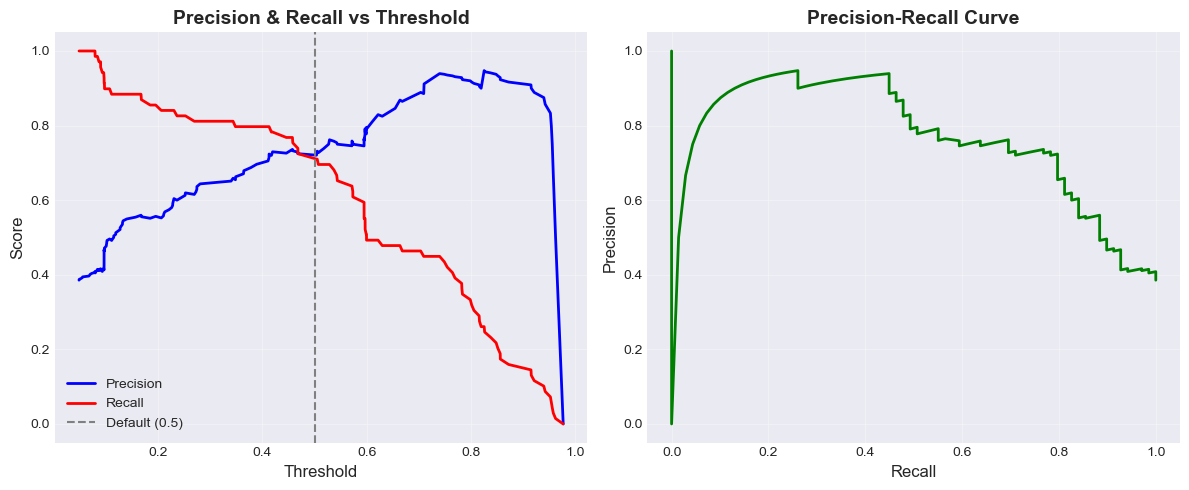

Interpretation:
  • Left plot: Shows how precision and recall change with different thresholds
  • Right plot: Precision-Recall curve - higher is better
  • The curves show the fundamental tradeoff between precision and recall


In [26]:
# Visualize the precision-recall tradeoff across many thresholds
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(12, 5))

# Plot 1: Precision and Recall vs Threshold
plt.subplot(1, 2, 1)
plt.plot(thresholds_pr, precisions[:-1], 'b-', label='Precision', linewidth=2)
plt.plot(thresholds_pr, recalls[:-1], 'r-', label='Recall', linewidth=2)
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision & Recall vs Threshold', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recalls, precisions, 'g-', linewidth=2)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("  • Left plot: Shows how precision and recall change with different thresholds")
print("  • Right plot: Precision-Recall curve - higher is better")
print("  • The curves show the fundamental tradeoff between precision and recall")

### ROC Curve and AUC Score

**ROC (Receiver Operating Characteristic) Curve** plots:

- **X-axis**: False Positive Rate (FPR) = $\frac{FP}{FP + TN}$ = "Of all actual negatives, how many did we incorrectly predict as positive?"
- **Y-axis**: True Positive Rate (TPR) = Recall = $\frac{TP}{TP + FN}$

**AUC (Area Under Curve)**: Measures the overall ability of the model to discriminate between classes

- AUC = 1.0: Perfect classifier
- AUC = 0.5: Random classifier (no better than flipping a coin)
- AUC > 0.8: Generally considered good

The ROC curve is **threshold-independent** - it shows model performance across all possible thresholds.

ROC-AUC Score: 0.8287

Interpretation: The model has a 82.9% probability of ranking
a randomly chosen positive example higher than a randomly chosen negative example.


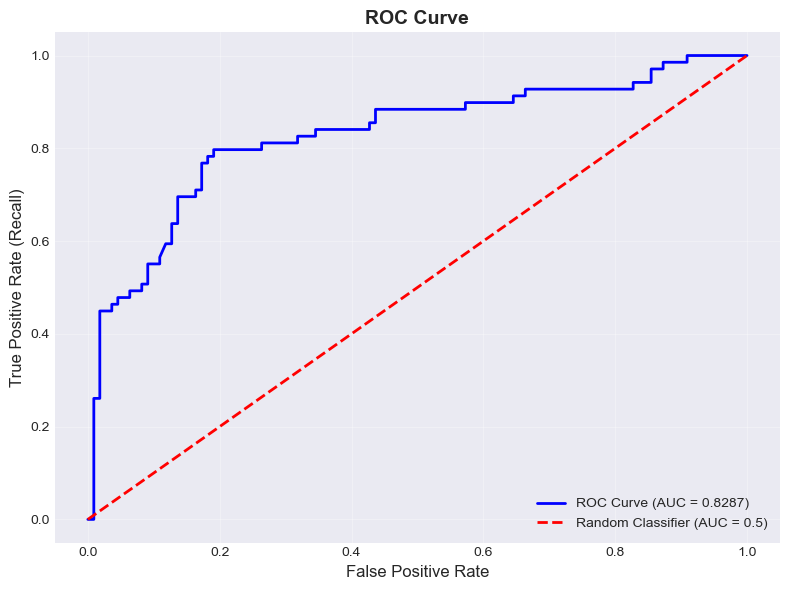


Key Points:
  ✓ AUC = 0.8287 indicates good discrimination ability
  ✓ Our model performs much better than random guessing
  ✓ ROC-AUC is useful for comparing models regardless of threshold choice


In [27]:
# Calculate ROC curve and AUC
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"\nInterpretation: The model has a {auc_score:.1%} probability of ranking")
print(f"a randomly chosen positive example higher than a randomly chosen negative example.")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey Points:")
print(f"  ✓ AUC = {auc_score:.4f} indicates {'good' if auc_score > 0.8 else 'moderate'} discrimination ability")
print(f"  ✓ Our model performs {'much ' if auc_score > 0.8 else ''}better than random guessing")
print(f"  ✓ ROC-AUC is useful for comparing models regardless of threshold choice")

### Summary: Choosing the Right Metric

Different metrics are appropriate for different situations:

| Metric | When to Use | What It Tells You |
|--------|-------------|-------------------|
| **Accuracy** | Balanced datasets | Overall correctness |
| **Precision** | False positives are costly (e.g., spam detection) | Quality of positive predictions |
| **Recall** | False negatives are costly (e.g., disease diagnosis) | Coverage of actual positives |
| **F1 Score** | Need balance between precision and recall | Harmonic mean of both |
| **ROC-AUC** | Comparing models, threshold-independent evaluation | Overall discrimination ability |

**For imbalanced datasets:**

- Don't rely solely on accuracy
- Consider precision, recall, and F1 score
- Use ROC-AUC for model comparison
- Choose your threshold based on the cost of different error types

**Next steps:**

- Experiment with different thresholds based on your use case
- Try different models and compare their ROC-AUC scores
- Consider techniques like class weighting or resampling for severe imbalance